In [ ]:
ưfrom google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!ls /content/drive/MyDrive/Flood/

data		 test_data.csv	 vietnam_similar_gauges_medium.csv
Flood_Duc.ipynb  train_data.csv  vietnam_training_dataset_1980_2014.csv


In [ ]:
#Load the overall dataset and then split it
import pandas as pd

df = pd.read_csv('vietnam_training_dataset_1980_2014.csv')

In [ ]:
df

,gauge_id,huc,date,year_x,month_x,day_x,basin_latitude,basin_elevation,basin_area,dayl,...,swe,tmax,tmin,vp,streamflow,quality,hour,year_y,month_y,day_y
0,1451800,2,1980-01-01,1980,1,1,40.59,205.0,137210693.0,32832.00,...,0.0,6.57,-7.50,360.00,90.0,A,12,1980,1,1
1,1451800,2,1980-01-02,1980,1,2,40.59,205.0,137210693.0,32832.00,...,0.0,5.10,-6.69,361.48,81.0,A,12,1980,1,2
2,1451800,2,1980-01-03,1980,1,3,40.59,205.0,137210693.0,33066.18,...,0.0,1.74,-4.43,440.00,74.0,A,12,1980,1,3
3,1451800,2,1980-01-04,1980,1,4,40.59,205.0,137210693.0,33177.61,...,0.0,-0.12,-9.37,293.44,67.0,A,12,1980,1,4
4,1451800,2,1980-01-05,1980,1,5,40.59,205.0,137210693.0,33177.61,...,0.0,-1.08,-7.74,340.78,67.0,A,12,1980,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369913,7362587,8,2014-10-16,2014,10,16,34.74,346.0,69899787.0,39743.99,...,0.0,23.02,3.14,766.42,5.1,A,12,2014,10,16
369914,7362587,8,2014-10-17,2014,10,17,34.74,346.0,69899787.0,39743.99,...,0.0,26.36,8.00,1080.13,3.7,A,12,2014,10,17
369915,7362587,8,2014-10-18,2014,10,18,34.74,346.0,69899787.0,39743.99,...,0.0,22.67,7.96,1076.41,2.7,A,12,2014,10,18
369916,7362587,8,2014-10-19,2014,10,19,34.74,346.0,69899787.0,39398.40,...,0.0,20.24,4.90,870.17,2.2,A,12,2014,10,19


In [ ]:
import pandas as pd

# Parameters
features = ['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']
target = ['streamflow']
day_depth = 2  # Use today and the day before and the day before

# Sort data properly
df = df.sort_values(by=['gauge_id', 'date']).reset_index(drop=True)

# Collect all processed groups
all_data = []

# Build sliding windows per gauge_id
for gauge_id, group in df.groupby('gauge_id'):
    group = group.copy().sort_values('date').reset_index(drop=True)

    lagged_feature_frames = []

    # Create lagged features: t-(day_depth-1), ..., t
    for lag in range(day_depth):
        lagged = group[features].shift(day_depth - 1 - lag)
        lagged.columns = [f"{col}_t-{day_depth - 1 - lag}" for col in features]
        lagged_feature_frames.append(lagged)

    # Combine all lagged features
    features_window = pd.concat(lagged_feature_frames, axis=1)

    # Get the target at time t
    target_series = group[target].reset_index(drop=True)

    # Also keep gauge_id for splitting later
    gauge_id_col = group[['gauge_id']].reset_index(drop=True)

    # Combine all
    full_data = pd.concat([gauge_id_col, features_window, target_series], axis=1)

    # Drop rows with NaN (due to shift)
    full_data = full_data.dropna().reset_index(drop=True)

    all_data.append(full_data)

# Combine all gauges
data = pd.concat(all_data, axis=0).reset_index(drop=True)

# Split: last 2 gauge_ids for test
unique_ids = sorted(data['gauge_id'].unique())
test_ids = unique_ids[-2:]
train = data[~data['gauge_id'].isin(test_ids)]
test = data[data['gauge_id'].isin(test_ids)]

# Save to CSV
train.to_csv("train_data.csv", index=False)
test.to_csv("test_data.csv", index=False)

print(f"✅ Done! Train shape: {train.shape}, Test shape: {test.shape}")

✅ Done! Train shape: (348046, 14), Test shape: (21842, 14)


In [ ]:
train

,gauge_id,dayl_t-1,prcp_t-1,srad_t-1,tmax_t-1,tmin_t-1,vp_t-1,dayl_t-0,prcp_t-0,srad_t-0,tmax_t-0,tmin_t-0,vp_t-0,streamflow
0,1451800,32832.00,0.00,270.39,6.57,-7.50,360.00,32832.00,0.00,255.52,5.10,-6.69,361.48,81.0
1,1451800,32832.00,0.00,255.52,5.10,-6.69,361.48,33066.18,0.00,168.92,1.74,-4.43,440.00,74.0
2,1451800,33066.18,0.00,168.92,1.74,-4.43,440.00,33177.61,0.00,230.01,-0.12,-9.37,293.44,67.0
3,1451800,33177.61,0.00,230.01,-0.12,-9.37,293.44,33177.61,1.15,183.18,-1.08,-7.74,340.78,67.0
4,1451800,33177.61,1.15,183.18,-1.08,-7.74,340.78,33177.61,0.00,242.19,0.06,-9.86,280.61,61.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348041,7196900,39052.79,0.00,321.16,24.18,11.75,1379.69,38707.20,0.00,248.94,20.04,11.54,1363.32,6.5
348042,7196900,38707.20,0.00,248.94,20.04,11.54,1363.32,38707.20,0.00,284.79,20.43,10.37,1269.83,5.8
348043,7196900,38707.20,0.00,284.79,20.43,10.37,1269.83,38674.17,0.00,326.79,25.93,12.62,1449.67,5.5
348044,7196900,38674.17,0.00,326.79,25.93,12.62,1449.67,38361.59,0.00,315.86,28.27,15.02,1721.64,5.2


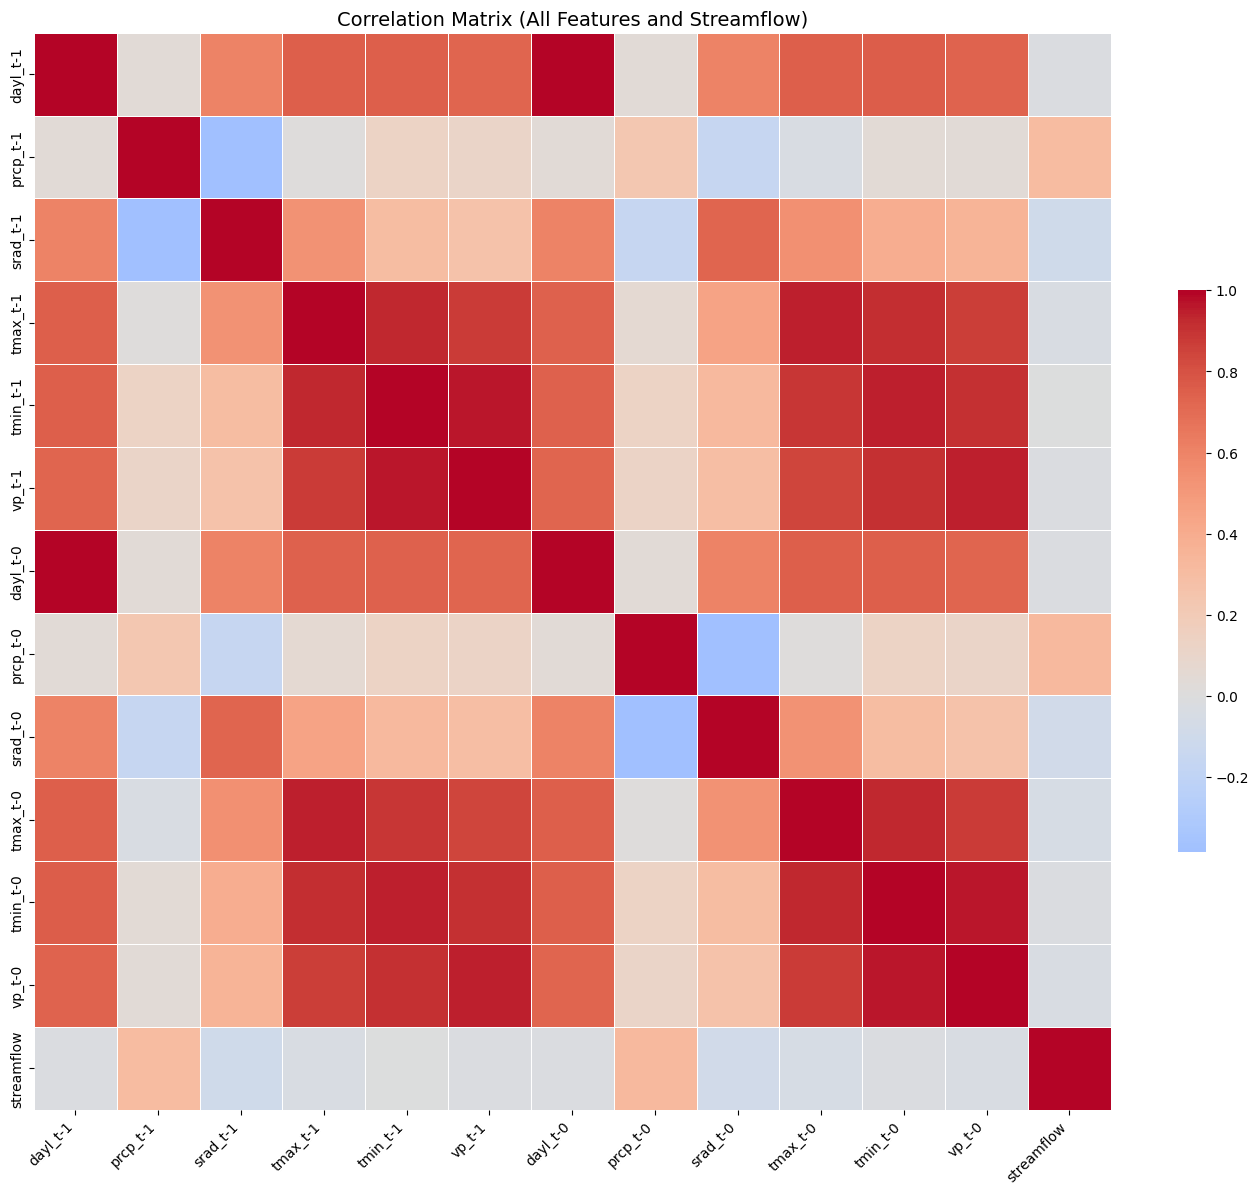

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the train dataset
train = pd.read_csv("train_data.csv")

# Drop non-numeric / ID columns
data_for_corr = train.drop(columns=["gauge_id"])

# Compute Pearson correlation matrix
corr_matrix = data_for_corr.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.5}, fmt=".2f")
plt.title("Correlation Matrix (All Features and Streamflow)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# Load data
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

# Features and target
feature_cols = [col for col in train_df.columns if col.startswith(tuple(['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']))]
target_col = 'streamflow'

# Normalize features
scaler = RobustScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

y_train = train_df[[target_col]].values
y_test = test_df[[target_col]].values

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)


Test MSE: 323338.7442
🔹 Saved scaler to scaler.pkl
🔹 Saved model to lr_model.h5


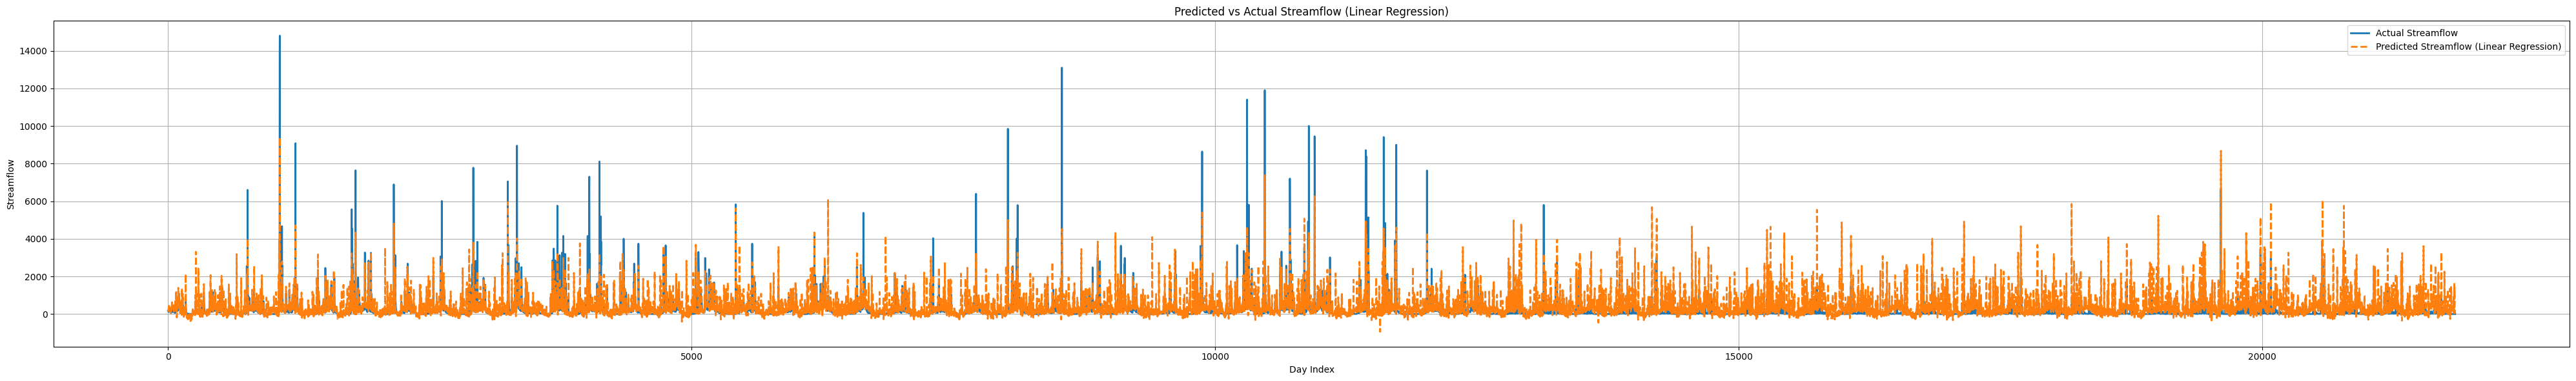

In [ ]:
import h5py
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Prepare data
X_train = train[feature_cols]
y_train = train['streamflow']
X_test = test[feature_cols]
y_test = test['streamflow']

# Train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

# 4. Persist scaler with joblib
joblib.dump(scaler, "scaler.pkl")
print("🔹 Saved scaler to scaler.pkl")

# 5. Persist model weights to HDF5
with h5py.File("lr_model.h5", "w") as f:
    f.create_dataset("coef", data=lr_model.coef_)
    f.create_dataset("intercept", data=lr_model.intercept_)
print("🔹 Saved model to lr_model.h5")

# Plot predictions vs actual
plt.figure(figsize=(40, 6))
plt.plot(y_test.values, label='Actual Streamflow', linewidth=2)
plt.plot(y_pred, label='Predicted Streamflow (Linear Regression)', linestyle='--', linewidth=2)
plt.xlabel("Day Index")
plt.ylabel("Streamflow")
plt.title("Predicted vs Actual Streamflow (Linear Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import h5py
import joblib

# 1) PARAMETERS (must match training)
features  = ['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']
day_depth = 2  # you used today and yesterday

# 2) LOAD RAW DATA
df = pd.read_csv("test_dataset_longdai.csv")
df['date'] = pd.to_datetime(df[['year','month','day']])
df = df.sort_values(['gauge_id','date']).reset_index(drop=True)

# 3) REBUILD LAGGED FEATURES
all_windows = []
for gid, grp in df.groupby('gauge_id'):
    grp = grp.sort_values('date').reset_index(drop=True)
    lag_frames = []
    for lag in range(day_depth):
        shifted = grp[features].shift(day_depth - 1 - lag)
        shifted.columns = [f"{c}_t-{day_depth-1-lag}" for c in features]
        lag_frames.append(shifted)
    window = pd.concat(lag_frames, axis=1)
    window = window.dropna().reset_index(drop=True)
    # carry over gauge_id and date of t
    window['gauge_id'] = gid
    window['date']     = grp.loc[window.index, 'date'].values
    all_windows.append(window)

data_new = pd.concat(all_windows, axis=0).reset_index(drop=True)

# 4) SELECT FEATURES IN THE SAME ORDER
feature_cols = [f"{c}_t-{d}" for d in range(day_depth-1, -1, -1) for c in features]
X_new = data_new[feature_cols]

# 5) LOAD SCALER & MODEL
scaler = joblib.load("scaler.pkl")          # your RobustScaler
with h5py.File("lr_model.h5", "r") as f:
    coef      = f["coef"][:]                # shape (n_features,)
    intercept = float(f["intercept"][()])   # scalar

# 6) TRANSFORM & PREDICT
X_scaled    = scaler.transform(X_new)
y_pred      = X_scaled.dot(coef.T) + intercept

# 7) ATTACH & SAVE
data_new["pred_streamflow"] = y_pred * 0.0283168
data_new.to_csv("predicted_streamflow.csv", index=False)
print("✅ Predictions saved to predicted_streamflow.csv")


✅ Predictions saved to predicted_streamflow.csv


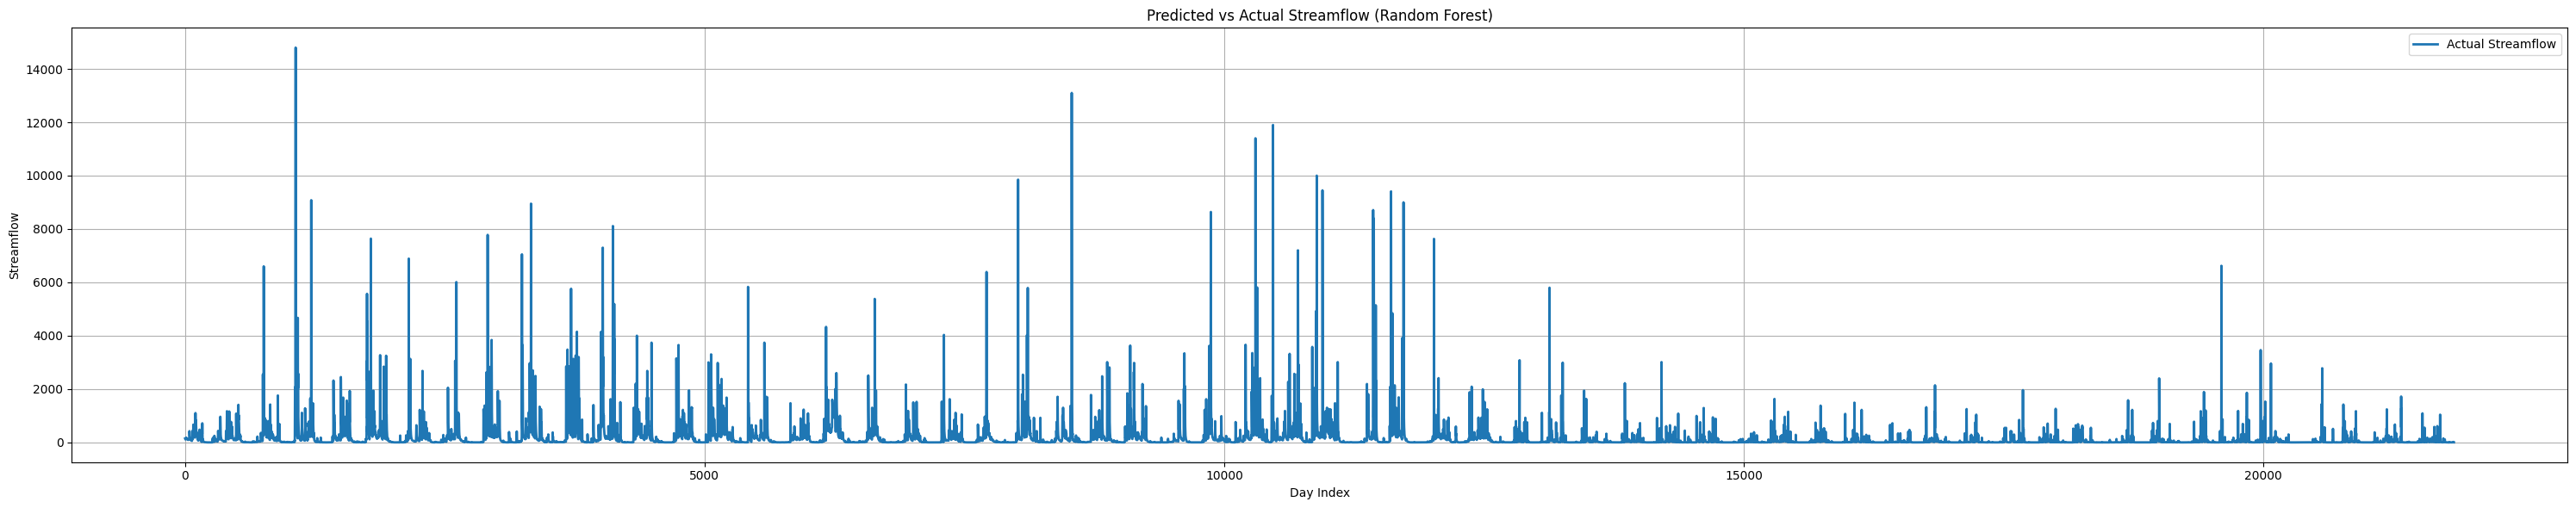

In [ ]:
# Plot predictions vs actual
plt.figure(figsize=(30, 6))
plt.plot(y_test.values, label='Actual Streamflow', linewidth=2)
# plt.plot(y_pred, label='Predicted Streamflow (Random Forest)', linestyle='--', linewidth=2)
plt.xlabel("Day Index")
plt.ylabel("Streamflow")
plt.title("Predicted vs Actual Streamflow (Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Features and target
feature_cols = [col for col in train_df.columns if col.startswith(tuple(['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']))]
target_col = 'streamflow'

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Prepare data
X_train = train[feature_cols]
y_train = train['streamflow']

# Train MLP regressor
mlp_model = MLPRegressor(hidden_layer_sizes=(64,20),
                         activation='relu',             # 'relu' is common for regression
                         solver='adam',                 # Optimizer
                         max_iter=500,                  # Increase if needed
                         random_state=42)
mlp_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


MLPRegressor(hidden_layer_sizes=(64, 20), max_iter=500, random_state=42)

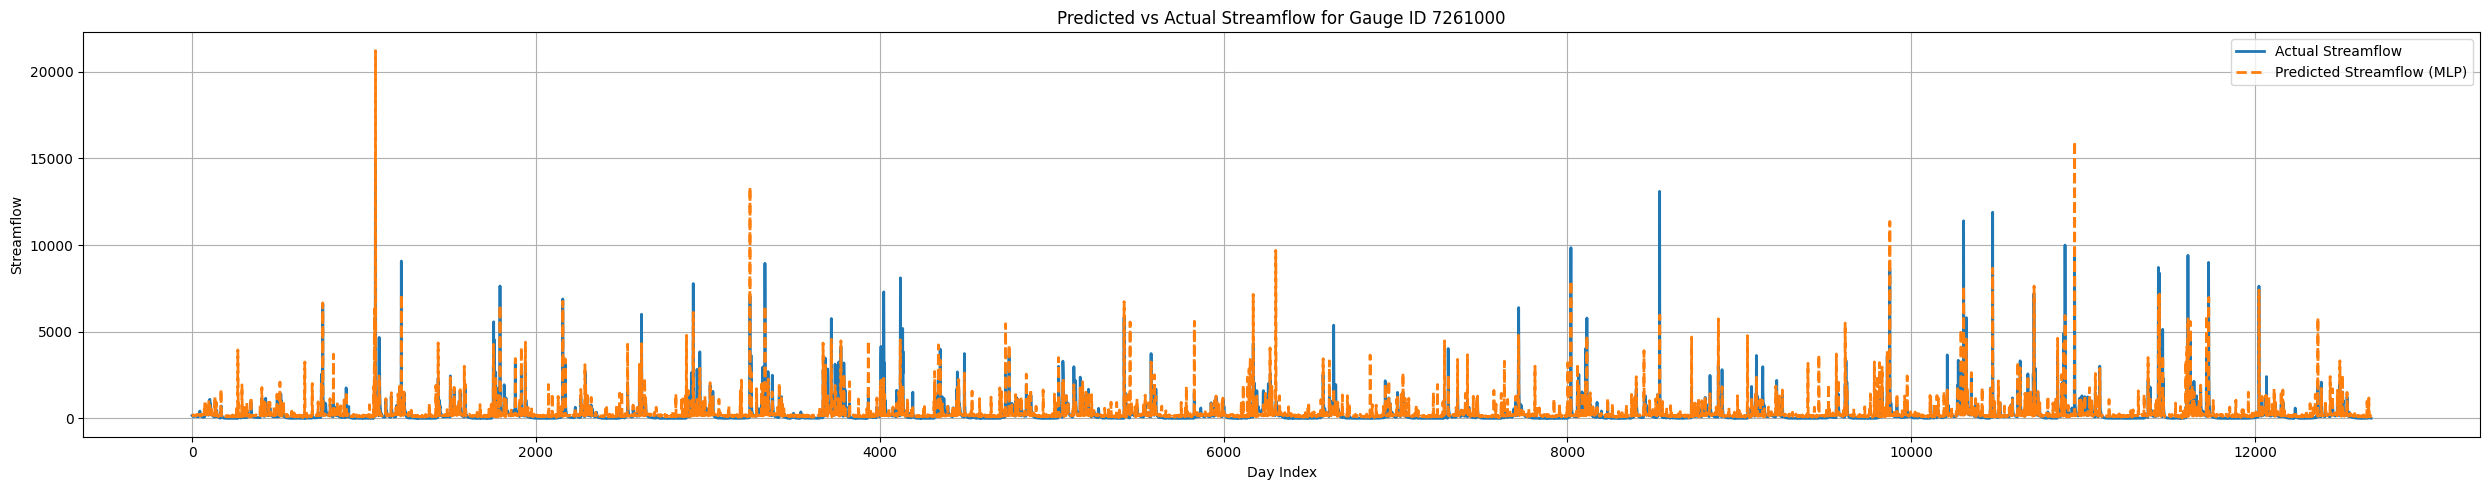

In [ ]:
# Choose a specific gauge_id from the test set to plot
selected_gauge_id = test['gauge_id'].unique()[0]  # Change index if needed

# Filter the test set for this gauge
test_subset = test[test['gauge_id'] == selected_gauge_id].copy()

# Extract features and ground truth
X_test_subset = test_subset[feature_cols]
y_test_subset = test_subset['streamflow']

# Predict for this gauge
y_pred_subset = mlp_model.predict(X_test_subset)

# Plot predictions vs actuals
plt.figure(figsize=(25, 5))
plt.plot(y_test_subset.values, label='Actual Streamflow', linewidth=2)
plt.plot(y_pred_subset, label='Predicted Streamflow (MLP)', linestyle='--', linewidth=2)
plt.xlabel("Day Index")
plt.ylabel("Streamflow")
plt.title(f"Predicted vs Actual Streamflow for Gauge ID {selected_gauge_id}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Features and target
feature_cols = [col for col in train_df.columns if col.startswith(tuple(['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']))]
target_col = 'streamflow'
print(feature_cols)

['dayl_t-1', 'prcp_t-1', 'srad_t-1', 'tmax_t-1', 'tmin_t-1', 'vp_t-1', 'dayl_t-0', 'prcp_t-0', 'srad_t-0', 'tmax_t-0', 'tmin_t-0', 'vp_t-0']


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Prepare data
X_train = train[feature_cols]
y_train = train['streamflow']

# Train MLP regressor
mlp_model = MLPRegressor(hidden_layer_sizes=(64,64,20),
                         activation='relu',             # 'relu' is common for regression
                         solver='adam',                 # Optimizer
                         max_iter=500,                  # Increase if needed
                         random_state=42)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
mlp_model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(64, 64, 20), max_iter=500, random_state=42)

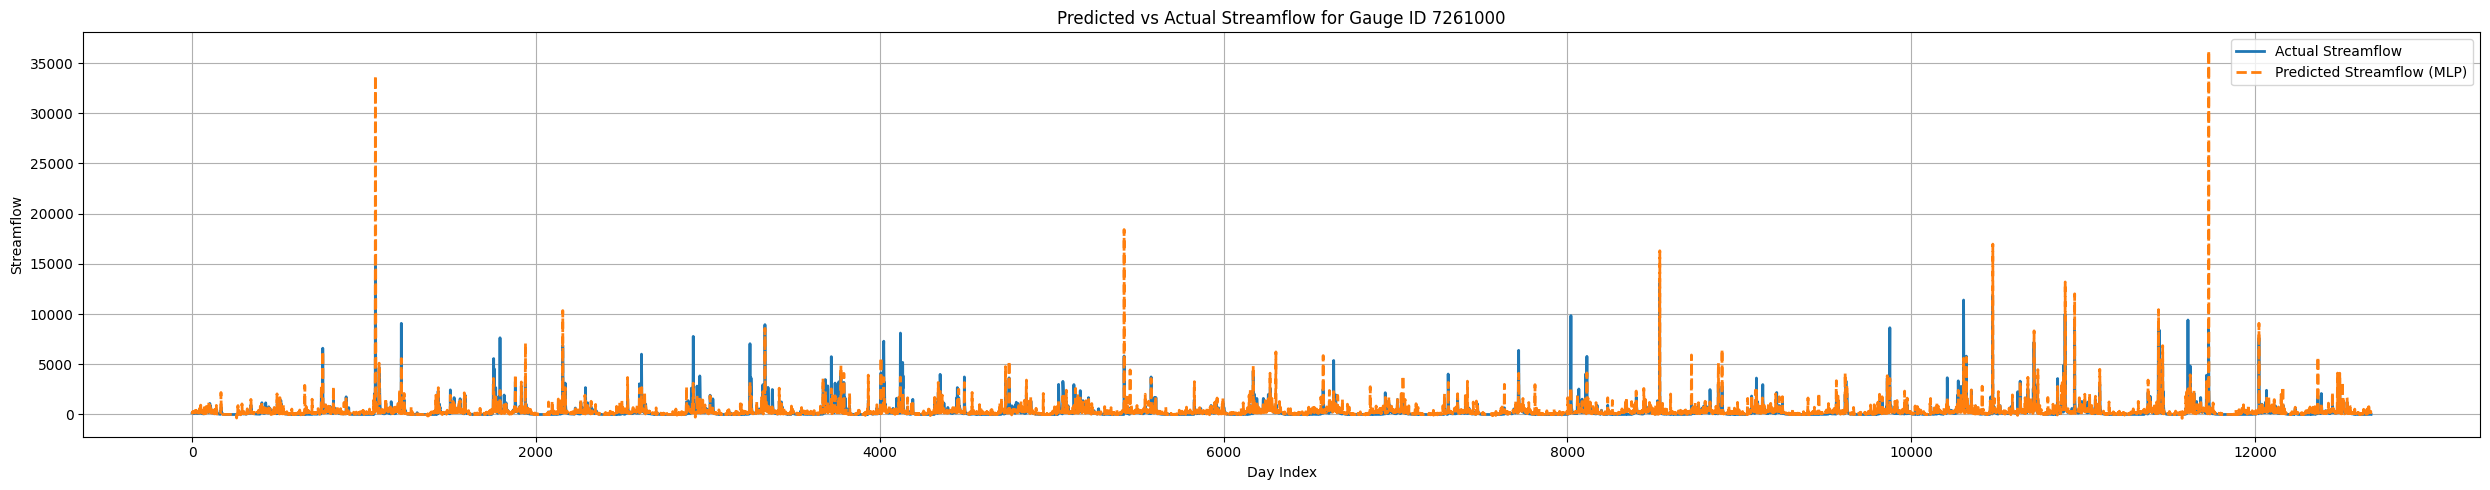

In [ ]:
# Choose a specific gauge_id from the test set to plot
selected_gauge_id = test['gauge_id'].unique()[0]  # Change index if needed

# Filter the test set for this gauge
test_subset = test[test['gauge_id'] == selected_gauge_id].copy()

# Extract features and ground truth
X_test_subset = test_subset[feature_cols]
y_test_subset = test_subset['streamflow']

# Predict for this gauge
y_pred_subset = mlp_model.predict(scaler.fit_transform(X_test_subset))

# Plot predictions vs actuals
plt.figure(figsize=(25, 5))
plt.plot(y_test_subset.values, label='Actual Streamflow', linewidth=2)
plt.plot(y_pred_subset, label='Predicted Streamflow (MLP)', linestyle='--', linewidth=2)
plt.xlabel("Day Index")
plt.ylabel("Streamflow")
plt.title(f"Predicted vs Actual Streamflow for Gauge ID {selected_gauge_id}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
test_longdai = pd.read_csv("test_dataset_longdai.csv")

In [ ]:
import pandas as pd

# Parameters
features = ['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']
day_depth = 2  # Number of days in sliding window

# Prepare DataFrame
df = test_longdai.copy()

# Sort by date
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df = df.sort_values(by='date').reset_index(drop=True)

# Create lagged features
lagged_feature_frames = []
for lag in range(day_depth):
    lagged = df[features].shift(day_depth - 1 - lag)
    lagged.columns = [f"{col}_t-{day_depth - 1 - lag}" for col in features]
    lagged_feature_frames.append(lagged)

# Combine lagged features
features_window = pd.concat(lagged_feature_frames, axis=1)

# Drop rows with NaNs from shifting only (not because of target)
features_window = features_window.dropna().reset_index(drop=True)

# Save or use this for prediction
features_window.to_csv("test_longdai_windowed_features_only.csv", index=False)

print(f"✅ Done! Shape of prediction-ready features: {features_window.shape}")


✅ Done! Shape of prediction-ready features: (374, 12)


In [ ]:
y_pred_subset = mlp_model.predict(scaler.fit_transform(features_window))

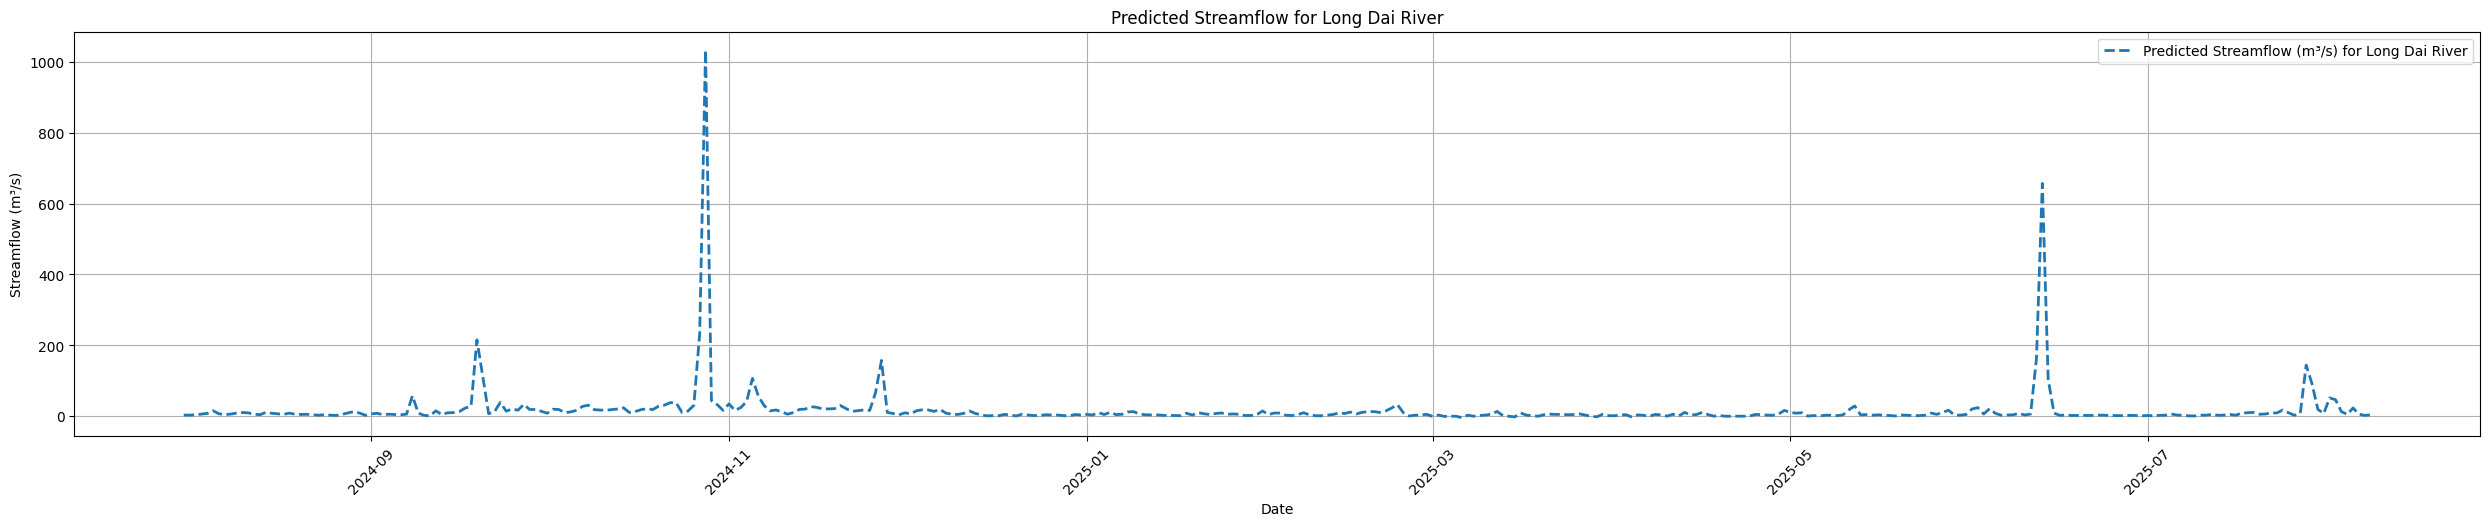

In [ ]:
# Convert predicted streamflow from cfs to m³/s
cfs_to_cms = 0.0283168
y_pred_subset_cms = y_pred_subset * cfs_to_cms

# Extract corresponding dates for y_pred_subset
start_index = day_depth - 1
aligned_dates = df['date'].iloc[start_index:start_index + len(y_pred_subset)].reset_index(drop=True)

# Plot predictions vs actuals in m³/s with dates
plt.figure(figsize=(25, 5))
plt.plot(aligned_dates, y_pred_subset_cms, label='Predicted Streamflow (m³/s) for Long Dai River', linestyle='--', linewidth=2)
plt.xlabel("Date")
plt.ylabel("Streamflow (m³/s)")
plt.title(f"Predicted Streamflow for Long Dai River")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd

# Combine aligned_dates and predictions into a single DataFrame
df_export = pd.DataFrame({
    'date': aligned_dates,
    'predicted_streamflow_cms': y_pred_subset_cms
})

# Export to CSV
df_export.to_csv('predicted_streamflow_long_dai.csv', index=False)
